## TS0: Generador de señales senoidales

La función `mi_funcion_sen` genera una señal de la forma:

$$x(t) = DC + V_{max} \cdot \sin(2\pi f t + \phi)$$

Parámetros:
- `vmax`: amplitud máxima (V)
- `dc`: valor medio o componente continua (V)
- `ff`: frecuencia (Hz)
- `ph`: fase inicial (radianes)
- `nn`: cantidad de muestras
- `fs`: frecuencia de muestreo (Hz)

### Paso 1

Importacion de las librerias a utilizar

In [14]:
import numpy as np
import matplotlib.pyplot as plt

### Paso 2

Defino la función *mi_funcion_sen()* con los parámetros solicitados en la consigna.
Agrego valores por defecto (en caso de que la utilice sin pasarle un input).

In [15]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

### Paso 3

Utilizo la función con los siguientes parametros:

- `vmax = 2` → amplitud máxima de 2 V
- `dc = 0.5` → valor medio de 0.5 V
- `ff = 5` → frecuencia de 5 Hz
- `ph = np.pi/4` → fase de π/4 radianes (45°)
- `nn = N = 1000` → 1000 muestras
- `fs = 1000` → frecuencia de muestreo de 1000 Hz

Realizo gráfico de la función resultante con librería => matplotlib.pyplot

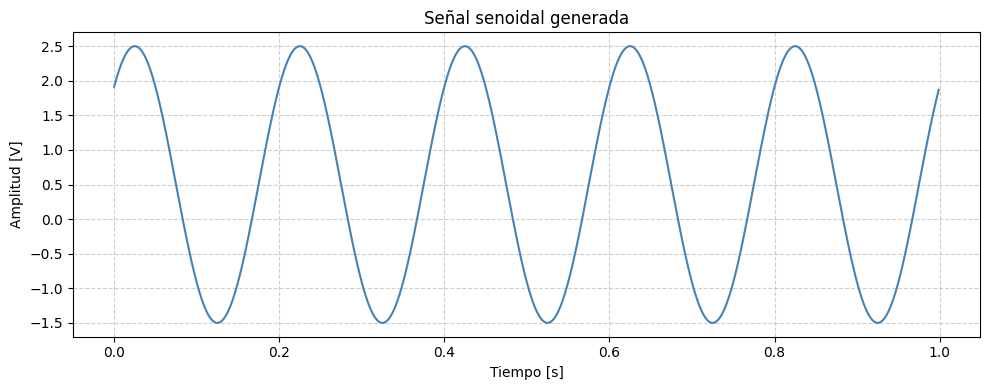

In [16]:
N  = 1000
fs = 1000

tt, xx = mi_funcion_sen(vmax=2, dc=0.5, ff=5, ph=np.pi/4, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Señal senoidal generada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Resultado 1

La función  *mi_funcion_sen()* devuelve como resultado:

- tt es el vector de tiempo: Contiene los instantes en segundos en los que el ADC tomó cada muestra
- xx es el vector de la señal: Contiene el valor de tensión (en volts) en cada uno de esos instantes.

En el gráfico se puede observar la senal senoidal generada correctamente.

### Bonus

Experimentos realizados en clase.

Siguiendo la notacion de la función original voy a usar los siguientes parametros fijos:
- `vmax = 1`
- `dc = 0`
- `ph = 0`
- `fs = 1000 Hz`
- `N = 1000`

Y voy a variar unicamente la frecuencia `ff` en cuatro casos: 500, 999, 1001 y 2001 Hz.

En base a la teoria vista en clase, la frecuencia de Nyquist para este sistema es `fs/2 = 500 Hz`, que es el limite teorico a partir del cual el ADC ya no puede representar correctamente una señal.

Por un tema de redundancia en el codigo y ya que solamente cambia la frecuencia en cada experimento voy a usar un bucle for 


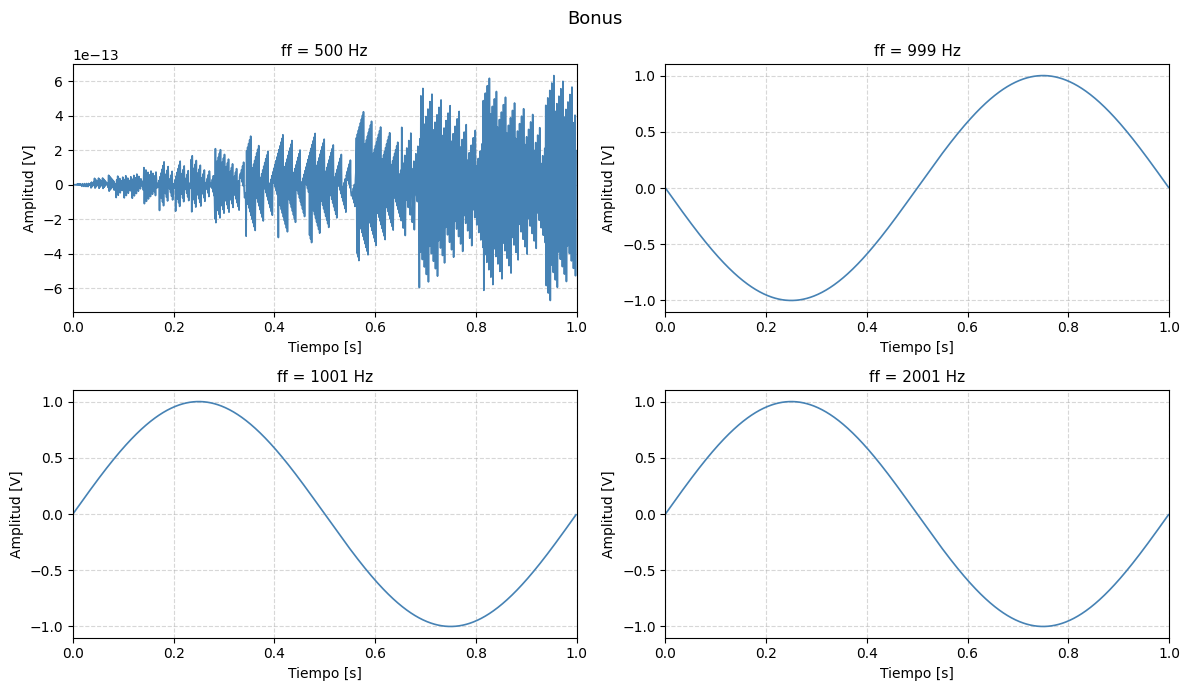

In [17]:
N  = 1000
fs = 1000

frecuencias = [500, 999, 1001, 2001]

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Bonus', fontsize=13)

for ax, ff in zip(axs.flat, frecuencias):
    tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)
    ax.plot(tt, xx, linewidth=1.2, color='steelblue')
    ax.set_title(f'ff = {ff} Hz', fontsize=11)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Amplitud [V]')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim([0, 1])  # zoom en las senales para ver mejor los ciclos

plt.tight_layout()
plt.show()

### Análisis de resultados

- **ff = 500 Hz** (esta frec es fs/2, frecuencia de Nyquist): la amplitud de la senal es muy chica (prácticamente cero). 
Esto ocurre porque con exactamente 2 muestras por 
ciclo y fase cero, todas las muestras caen justo en los cruces por cero de la senoidal.

- **ff = 999 Hz**: se produce **aliasing**. La señal de 999 Hz es indistinguible para el ADC de una señal de 1 Hz, ya que `fs - ff = 1000 - 999 = 1 Hz`. Se observa exactamente un ciclo completo en el segundo graficado.

- **ff = 1001 Hz**: mismo fenómeno. Una señal de 1001 Hz aparece también como 1 Hz (`ff - fs = 1001 - 1000 = 1 Hz`). El gráfico es casi idéntico al caso anterior, con la única diferencia de que la fase está invertida.

- **ff = 2001 Hz**: la señal de 2001 Hz alias igualmente a 1 Hz (`ff - 2*fs = 2001 - 2000 = 1 Hz`). 

Cualquier frecuencia que supere `fs/2` genera aliasing: la señal muestreada aparenta tener una frecuencia completamente distinta a la real, y esa información se pierde de forma irreversible. Por eso el teorema de Nyquist establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima de la señal.

### Otras señales

Implemento una señal cuadrada



In [18]:
from scipy.signal import square

def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, duty=0.5):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * square(2 * np.pi * ff * tt + ph, duty=duty)
    return tt, xx

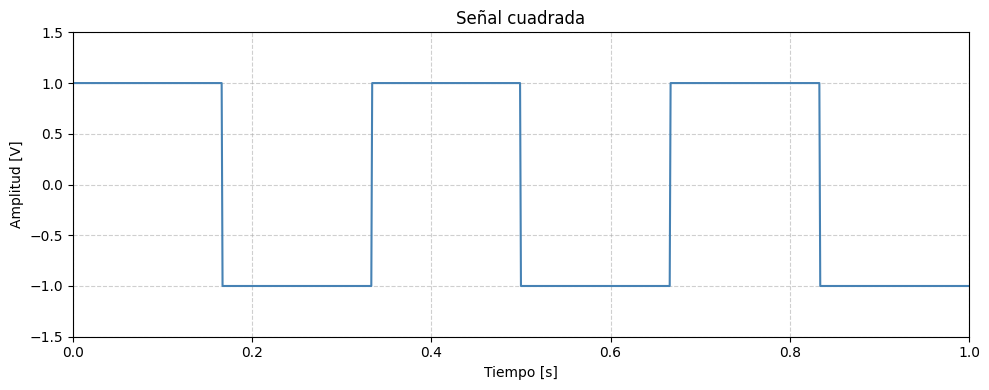

In [19]:
N  = 1000
fs = 1000

tt, xx = mi_funcion_cuadrada(vmax=1, dc=0, ff=3, ph=0, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Señal cuadrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim([-1.5, 1.5])
plt.xlim([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Implemento una señal Pulso Gaussiano

In [20]:
from scipy.signal import gausspulse

def mi_funcion_gausspulse(vmax=1, dc=0, fc=10, bw=0.5, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    t_centered = tt - tt.mean()
    xx = dc + vmax * gausspulse(t_centered, fc=fc, bw=bw)
    return tt, xx

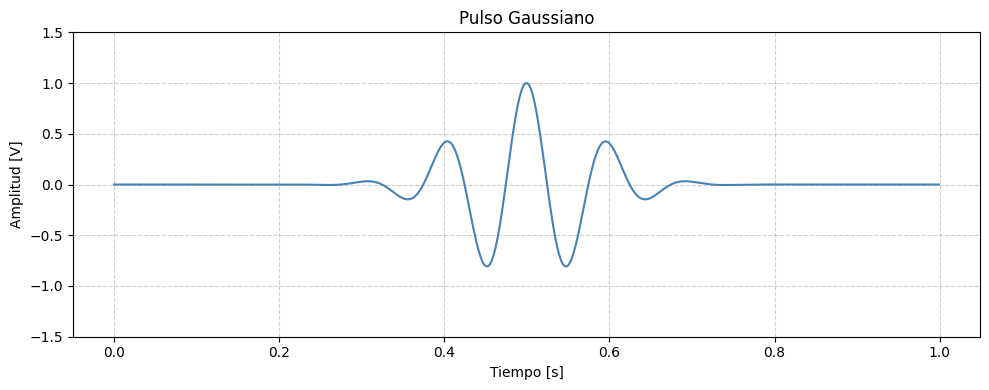

In [21]:
N  = 1000
fs = 1000

tt, xx = mi_funcion_gausspulse(vmax=1, dc=0, fc=10, bw=0.5, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Pulso Gaussiano')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim([-1.5, 1.5])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Señal senoidal contaminada con ruido

Hasta acá todas las señales generadas fueron determinísticas. Ahora genero una señal **aleatoria** (ruido) y la sumo a la senoidal para obtener una nueva señal:

$$x'(t) = x(t) + n(t)$$

donde:
- `x(t)` es la senoidal generada con *mi_funcion_sen()*, **normalizada a 1 W de potencia**
- `n(t)` es ruido blanco gaussiano de media nula y varianza $\sigma^2$

El ruido lo genero con `np.random.normal(mu, sigma, N)`, que devuelve muestras independientes de una distribución normal (gaussiana). Al ser **blanco**, cada muestra es independiente de la anterior, por lo que su energía se reparte de manera uniforme en todo el espectro.

### ¿Por qué la senoidal de 1 W?

La potencia media de una señal y su varianza se relacionan así:

$$P_x = \frac{1}{N}\sum_{k=0}^{N-1} |x[k]|^2 = \sigma_x^2 + \mu_x^2$$

Como trabajo con `dc = 0`, el valor medio es nulo ($\mu_x = 0$) y entonces **la potencia es directamente la varianza**, que verifico con `np.var(xx)`.

Para una senoidal de media nula, $P_x = V_{max}^2/2$, así que despejando para $P_x = 1$ W:

$$V_{max} = \sqrt{2} \approx 1.4142\ V$$

La ventaja de normalizar a 1 W es que el SNR queda determinado únicamente por la potencia del ruido:

$$SNR_{dB} = 10\log_{10}\left(\frac{1}{\sigma^2}\right) = -20\log_{10}(\sigma)$$

In [22]:
def mi_funcion_ruido(sigma=0.1, mu=0, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    nn_ruido = np.random.normal(mu, sigma, (nn, 1))
    return tt, nn_ruido


N  = 1000
fs = 1000

np.random.seed(0)  # semilla fija para que el experimento sea reproducible

# Señal util: senoidal de 1 W -> Vmax = sqrt(2), sin componente de continua
vmax_1w = np.sqrt(2)
tt, xx = mi_funcion_sen(vmax=vmax_1w, dc=0, ff=5, ph=0, nn=N, fs=fs)

# Verifico la potencia con la varianza (vale porque la media es nula)
print(f'Amplitud       Vmax       = {vmax_1w:.4f} V')
print(f'Valor medio    np.mean(x) = {np.mean(xx):.2e} V   (debe ser ~0)')
print(f'Potencia       np.var(x)  = {np.var(xx):.6f} W   (debe ser 1)')

# Señal de ruido: gaussiana de media nula y desvio 0.5 V
_, nn_ruido = mi_funcion_ruido(sigma=0.5, mu=0, nn=N, fs=fs)

# Nueva señal x' = x + ruido
xx_ruidosa = xx + nn_ruido

Amplitud       Vmax       = 1.4142 V
Valor medio    np.mean(x) = -8.53e-17 V   (debe ser ~0)
Potencia       np.var(x)  = 1.000000 W   (debe ser 1)


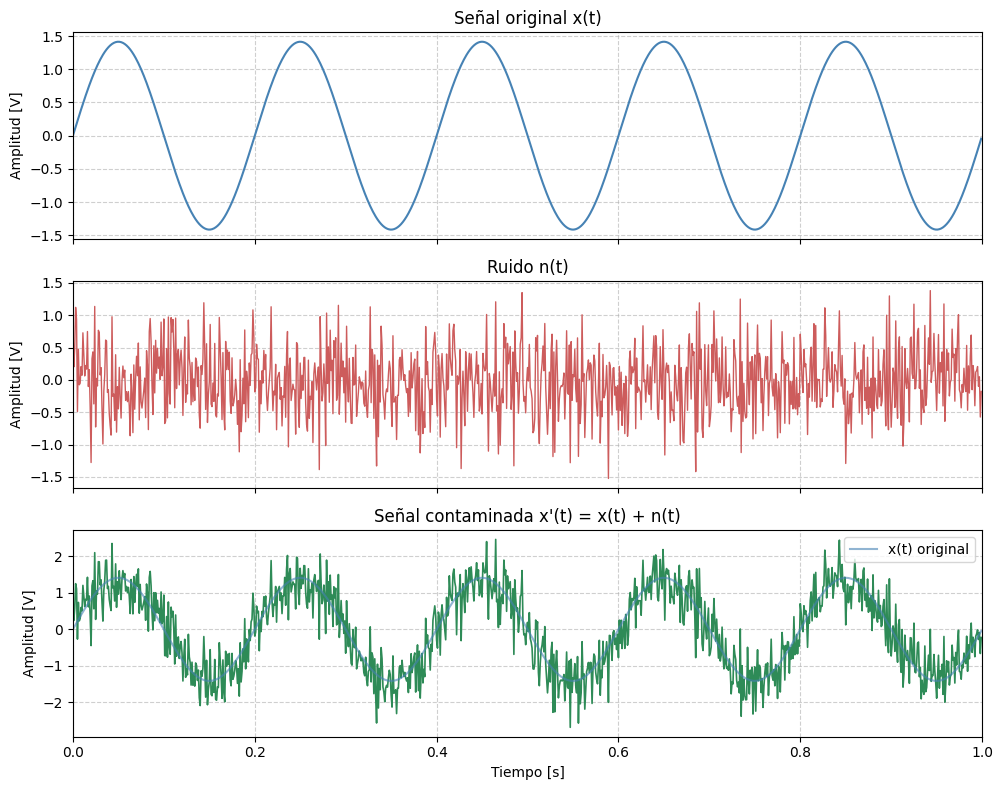

In [23]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(tt, xx, linewidth=1.5, color='steelblue')
axs[0].set_title('Señal original x(t)')
axs[0].set_ylabel('Amplitud [V]')

axs[1].plot(tt, nn_ruido, linewidth=1.0, color='indianred')
axs[1].set_title('Ruido n(t)')
axs[1].set_ylabel('Amplitud [V]')

axs[2].plot(tt, xx_ruidosa, linewidth=1.2, color='seagreen')
axs[2].plot(tt, xx, linewidth=1.5, color='steelblue', alpha=0.6, label='x(t) original')
axs[2].set_title("Señal contaminada x'(t) = x(t) + n(t)")
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Amplitud [V]')
axs[2].legend(loc='upper right')

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

### Cálculo del SNR

El SNR (*Signal to Noise Ratio*) es la relación entre la potencia de la señal útil y la potencia del ruido. Se suele expresar en decibeles:

$$SNR_{dB} = 10 \cdot \log_{10}\left(\frac{P_x}{P_n}\right)$$

Como tanto la señal como el ruido tienen media nula, sus potencias son sus varianzas, así que puedo calcular todo con `np.var()`:

$$SNR_{dB} = 10 \cdot \log_{10}\left(\frac{\sigma_x^2}{\sigma_n^2}\right) = 10 \cdot \log_{10}\left(\frac{\texttt{np.var(xx)}}{\texttt{np.var(nn\_ruido)}}\right)$$

Valores teóricos esperados:

- Señal normalizada: $P_x = 1$ W
- Ruido gaussiano de media nula y desvío $\sigma$: $P_n = \sigma^2$

Con $\sigma = 0.5$ V queda:

$$SNR_{dB} = 10 \cdot \log_{10}\left(\frac{1}{0.25}\right) = 10 \cdot \log_{10}(4) \approx 6.02\ dB$$

In [24]:
def calcular_snr(xx, nn_ruido):
    """SNR en dB entre la señal util xx y el ruido nn_ruido.

    Uso la varianza como medida de potencia: vale porque ambas
    señales tienen valor medio nulo (Px = var + media^2).
    """
    return 10 * np.log10(np.var(xx) / np.var(nn_ruido))


# Potencias medidas sobre las muestras generadas
Px  = np.var(xx)
Pn  = np.var(nn_ruido)
Pxr = np.var(xx_ruidosa)

snr_db = calcular_snr(xx, nn_ruido)

# Valores teoricos para comparar
sigma = 0.5
snr_teo = 10 * np.log10(1 / sigma ** 2)

print(f'Potencia de la señal   Px  = np.var(xx)         = {Px:.4f} W   (teorica: 1.0000 W)')
print(f'Potencia del ruido     Pn  = np.var(nn_ruido)   = {Pn:.4f} W   (teorica: {sigma**2:.4f} W)')
print(f"Potencia de x'         Px' = np.var(xx_ruidosa) = {Pxr:.4f} W   (~ Px + Pn = {Px + Pn:.4f} W)")
print()
print(f'SNR medido   = {snr_db:.2f} dB')
print(f'SNR teorico  = {snr_teo:.2f} dB')

Potencia de la señal   Px  = np.var(xx)         = 1.0000 W   (teorica: 1.0000 W)
Potencia del ruido     Pn  = np.var(nn_ruido)   = 0.2436 W   (teorica: 0.2500 W)
Potencia de x'         Px' = np.var(xx_ruidosa) = 1.2189 W   (~ Px + Pn = 1.2436 W)

SNR medido   = 6.13 dB
SNR teorico  = 6.02 dB


### Barrido de niveles de ruido

Para ver cómo impacta el ruido sobre la señal, repito el experimento variando el desvío estándar $\sigma$ y calculo el SNR en cada caso.

Como la señal está normalizada a 1 W, el SNR esperado sale directo de $\sigma$: $SNR_{dB} = -20\log_{10}(\sigma)$, o sea 20, 6, 0 y -6 dB respectivamente.

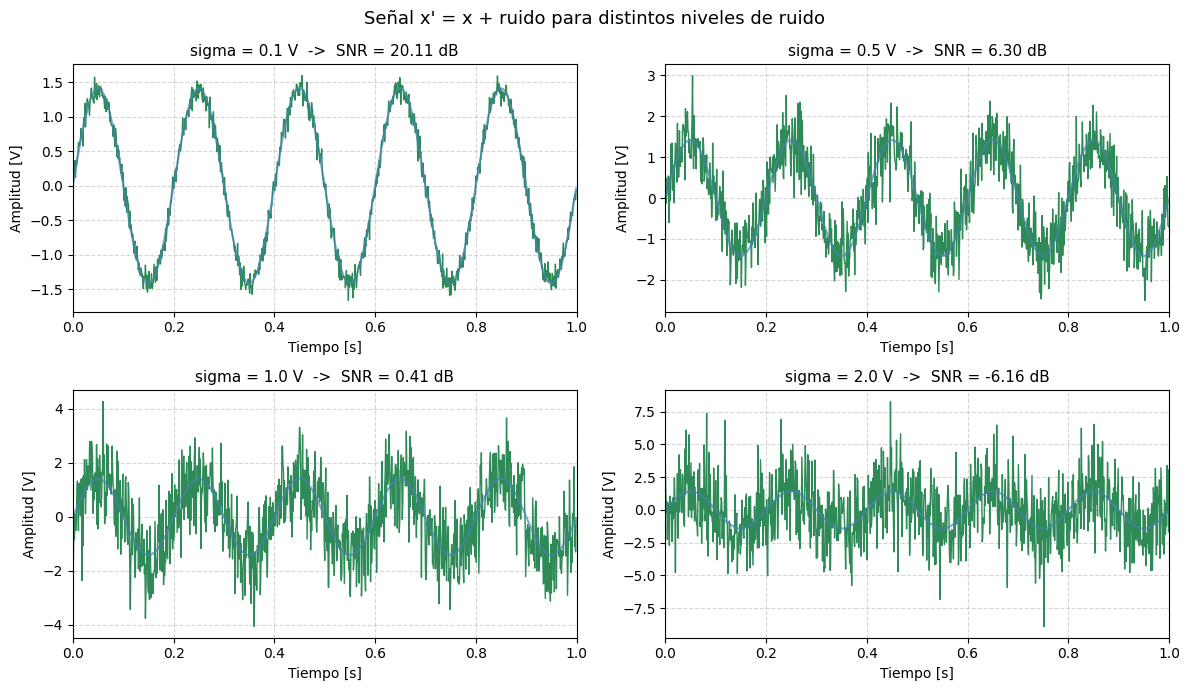

In [27]:
np.random.seed(0)

sigmas = [0.1, 0.5, 1.0, 2.0]

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Señal x' = x + ruido para distintos niveles de ruido", fontsize=13)

for ax, sigma in zip(axs.flat, sigmas):
    _, nn_i = mi_funcion_ruido(sigma=sigma, mu=0, nn=N, fs=fs)
    xx_i = xx + nn_i
    snr_i = calcular_snr(xx, nn_i)

    ax.plot(tt, xx_i, linewidth=1.0, color='seagreen')
    ax.plot(tt, xx, linewidth=1.5, color='steelblue', alpha=0.7)
    ax.set_title(f'sigma = {sigma} V  ->  SNR = {snr_i:.2f} dB', fontsize=11)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Amplitud [V]')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

### Análisis de resultados

- La verificación con `np.var(xx)` da 1 W: la senoidal de $V_{max} = \sqrt{2}$ está correctamente normalizada en potencia. Como el valor medio es nulo, varianza y potencia media coinciden ($P_x = \sigma_x^2 + \mu_x^2$), y por eso `np.var()` alcanza para controlarlo.

- El SNR **medido** queda muy cerca del **teórico** ($-20\log_{10}(\sigma)$). La pequeña diferencia se debe a que con N finito la varianza estimada del ruido no es exactamente $\sigma^2$: es una estimación que converge al valor real a medida que aumenta la cantidad de muestras.

- Como la señal y el ruido son **incorrelados** y ambos tienen media nula, las potencias se suman: $P_{x'} \approx P_x + P_n$. Esto se verifica en los valores impresos.

- Al estar la señal normalizada a 1 W, el SNR se lee directamente de $\sigma$: con $\sigma = 0.1$ V da ≈ 20 dB, con $\sigma = 0.5$ V ≈ 6 dB, con $\sigma = 1$ V ≈ 0 dB y con $\sigma = 2$ V ≈ -6 dB. Cada vez que se duplica $\sigma$ el SNR cae 6 dB, porque la potencia del ruido se cuadruplica.

- Un SNR de 0 dB ($\sigma = 1$ V) es el punto en el que señal y ruido tienen exactamente la misma potencia; valores negativos implican que el ruido domina y la senoidal queda prácticamente enmascarada en el dominio temporal.